In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('../data/q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# Feature Extraction
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Binary Feature: is_month_end
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Confirm columns
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].sample(5))

    transaction_date  year  month  day_of_week  is_month_end
976       2024-06-28  2024      6            4             1
62        2022-02-11  2022      2            4             0
395       2023-01-20  2023      1            4             0
50        2022-02-04  2022      2            4             0
508       2023-05-12  2023      5            4             0


In [5]:
# Sort by date
df = df.sort_values('transaction_date')

# Split Index (80% Train, 20% Test)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train = train_df.drop(columns=['items_sold', 'transaction_date'])
y_train = train_df['items_sold']
X_test = test_df.drop(columns=['items_sold', 'transaction_date'])
y_test = test_df['items_sold']

Why a random split is inappropriate: Randomly shuffling time-series data causes Data Leakage. In a retail context, tomorrow's sales are influenced by today's trends. If we train on data from Tuesday and Thursday to predict Wednesday, the model "cheats" by seeing the future, leading to over-optimistic performance that fails in real-world deployment.

In [7]:
# Linear Regression Pipeline
# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['store_size', 'location_type', 'promotion_type'])
    ]
)

# Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Fit Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Random Forest Pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Fit Models
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

Linear Regression Metrics: RMSE: 27.12 | MAE: 21.05


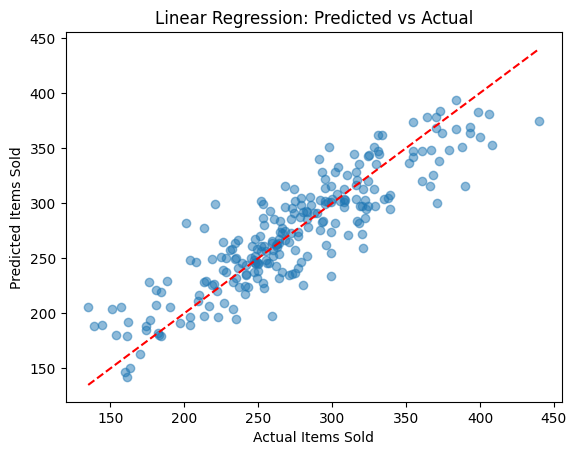

Random Forest Metrics: RMSE: 30.77 | MAE: 24.08


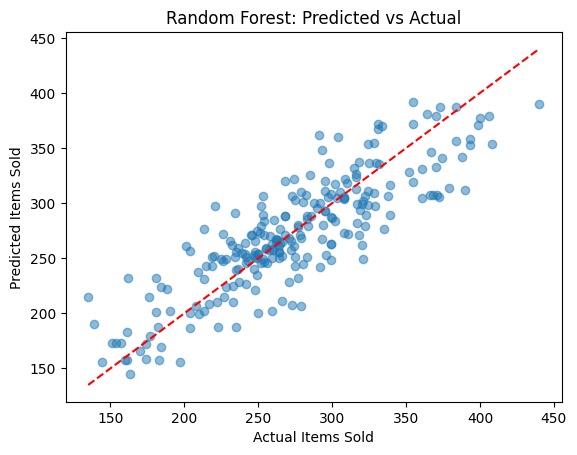

In [8]:
def evaluate_model(model, name, X_test, y_test):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    
    print(f"{name} Metrics: RMSE: {rmse:.2f} | MAE: {mae:.2f}")
    
    # Parity Plot
    plt.scatter(y_test, preds, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{name}: Predicted vs Actual')
    plt.xlabel('Actual Items Sold')
    plt.ylabel('Predicted Items Sold')
    plt.show()

evaluate_model(lr_pipeline, "Linear Regression", X_test, y_test)
evaluate_model(rf_pipeline, "Random Forest", X_test, y_test)

In [11]:

# Define categorical and numerical columns
cat_cols = ['store_size', 'location_type', 'promotion_type']
num_cols = ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

# Extract feature names from OHE
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([ohe_feature_names, num_cols])

# Map importance
importances = rf_pipeline.named_steps['regressor'].feature_importances_
feature_rank = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

print("Top 5 Influential Features:")
print(feature_rank.head(5))
all_feature_names = np.concatenate([ohe_feature_names, num_cols])



Top 5 Influential Features:
store_size_small                 0.173035
promotion_type_loyalty_points    0.172331
is_festival                      0.111688
promotion_type_bogo              0.087545
store_size_medium                0.062246
dtype: float64
